# 2주차 코딩실습 정답
현재 배포된 2주차 실습문제 5개의 완성 코드, 실행 결과와 해설입니다.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
torch.manual_seed(0)

## 공통 선형 분류 모델 학습

In [2]:
X = torch.randn(100, 2)
y = (X[:, 0] + X[:, 1] > 0).float()
model = nn.Sequential(nn.Linear(2, 1), nn.Sigmoid())
optimizer = optim.SGD(model.parameters(), lr=0.1)
criterion = nn.BCELoss()
for _ in range(50):
    optimizer.zero_grad()
    loss = criterion(model(X).squeeze(), y)
    loss.backward()
    optimizer.step()

## 문제 1. 선형 분류 정확도 계산

In [3]:
with torch.no_grad():
    probability = model(X).squeeze()
    for threshold in [0.3, 0.5, 0.7]:
        prediction = (probability > threshold).long()
        accuracy = (prediction == y.long()).float().mean()
        print(f'threshold={threshold:.1f}, accuracy={accuracy.item():.3f}')

threshold=0.3, accuracy=0.690
threshold=0.5, accuracy=0.890
threshold=0.7, accuracy=0.750


임계값이 커지면 양성(1)으로 판정되는 표본 수가 줄고, 작아지면 늘어납니다. 정확도는 데이터의 클래스 분포와 예측 확률에 따라 달라집니다.

## 문제 2. K-means의 군집 수 변경

iterations: 6
centroids:
 tensor([[-2.9489, -0.1053],
        [ 2.9700, -0.0695],
        [ 0.0721,  3.1423]])


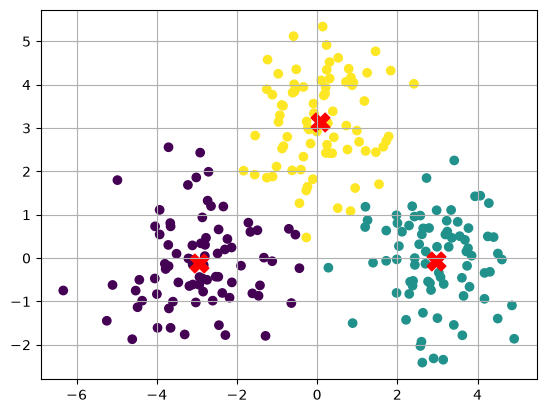

In [4]:
torch.manual_seed(1)
X3 = torch.cat([
    torch.randn(80, 2) + torch.tensor([-3., 0.]),
    torch.randn(80, 2) + torch.tensor([0., 3.]),
    torch.randn(80, 2) + torch.tensor([3., 0.])
])
centroids = X3[torch.randperm(X3.size(0))[:3]]
for step in range(30):
    distances = torch.cdist(X3, centroids)
    labels = distances.argmin(dim=1)
    new_centroids = torch.stack([X3[labels == i].mean(dim=0) for i in range(3)])
    if torch.allclose(centroids, new_centroids):
        break
    centroids = new_centroids
print('iterations:', step + 1)
print('centroids:\n', centroids)
plt.scatter(X3[:, 0], X3[:, 1], c=labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=180, marker='X')
plt.grid(True); plt.show()

## 문제 3. 학습률 비교 실험

lr=0.001: final loss=10.6417
lr=0.01: final loss=0.607442
lr=0.1: final loss=0
lr=0.5: final loss=1.95063e+19


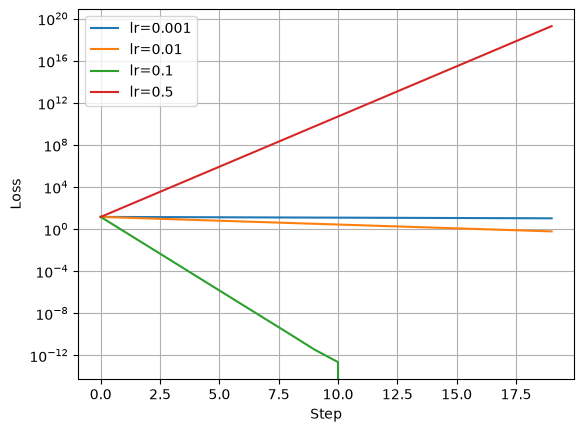

In [5]:
def run_lr(rate, steps=20):
    w = torch.tensor([0.1], requires_grad=True)
    optimizer = optim.SGD([w], lr=rate)
    history = []
    for _ in range(steps):
        optimizer.zero_grad()
        loss = (w * 2.0 - 4.0).pow(2).mean()
        loss.backward(); optimizer.step()
        history.append((w.item(), loss.item()))
    return history
for rate in [0.001, 0.01, 0.1, 0.5]:
    history = run_lr(rate, 20)
    losses = [item[1] for item in history]
    plt.plot(losses, label=f'lr={rate}')
    print(f'lr={rate}: final loss={losses[-1]:.6g}')
plt.yscale('log'); plt.xlabel('Step'); plt.ylabel('Loss')
plt.legend(); plt.grid(True); plt.show()

이 예제에서는 0.1이 빠르고 안정적으로 수렴합니다. 0.001과 0.01은 더 느리고, 0.5는 최솟값을 지나치며 발산합니다.

## 문제 4. 수동 경사하강법 구현

In [6]:
x = torch.tensor(2.0); y_true = torch.tensor(4.0)
w = torch.tensor(0.1, requires_grad=True); lr = 0.1
for step in range(10):
    loss = (w * x - y_true) ** 2
    loss.backward()
    with torch.no_grad():
        w -= lr * w.grad
    w.grad.zero_()
    print(step, round(w.item(), 6), round(loss.item(), 6))

0 1.62 14.44
1 1.924 0.5776
2 1.9848 0.023104
3 1.99696 0.000924
4 1.999392 3.7e-05
5 1.999878 1e-06
6 1.999976 0.0
7 1.999995 0.0
8 1.999999 0.0
9 2.0 0.0


## 문제 5. 비선형 데이터 분류

In [7]:
X_xor = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y_xor = torch.tensor([[0.], [1.], [1.], [0.]])
def train_xor(model, steps=1000):
    optimizer = optim.Adam(model.parameters(), lr=0.05)
    criterion = nn.BCEWithLogitsLoss()
    for _ in range(steps):
        optimizer.zero_grad()
        loss = criterion(model(X_xor), y_xor)
        loss.backward(); optimizer.step()
    with torch.no_grad():
        pred = (torch.sigmoid(model(X_xor)) >= 0.5).float()
        return (pred == y_xor).float().mean().item(), pred.squeeze().tolist()
torch.manual_seed(0)
linear_model = nn.Linear(2, 1)
torch.manual_seed(0)
nonlinear_model = nn.Sequential(nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 1))
print('linear:', train_xor(linear_model))
print('nonlinear:', train_xor(nonlinear_model))

linear: (0.5, [1.0, 1.0, 1.0, 1.0])


nonlinear: (1.0, [0.0, 1.0, 1.0, 0.0])


XOR은 하나의 직선으로 네 점을 완벽히 분리할 수 없습니다. 은닉층과 ReLU를 넣으면 비선형 결정 경계를 만들 수 있어 완전 분류가 가능합니다.